# **Classifying Political Bias of News Articles - Report**

---

## Comments

This notebook implements a PySpark machine-learning pipeline for classifying news articles by political leaning using title and article text. The completed workflow includes data loading, preprocessing, exploratory checks, model selection, formal parameter tuning, evaluation, confusion matrix visualisation, and legal/social/ethical/professional considerations.

# **Initiate and Configure Spark**


In [2]:
# Purpose: Start Spark and import required PySpark, ML, plotting, and utility libraries.

from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.functions import (
    col, regexp_replace, substring, concat_ws, lower, trim,
    count, round, when
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml.classification import LogisticRegression, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

spark = (
    SparkSession.builder
    .appName("Political Bias Classification")
    .master("local[*]")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

VIEW = True
RESULTS = True

print("Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 20:08:33 WARN Utils: Your hostname, Wizrds-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.136.11.24 instead (on interface en0)
26/04/26 20:08:33 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 20:08:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/26 20:08:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


# **Data chosen and Research objectives**

## Dataset chosen

I set out to apply machine learning techniques to text-based data via text mining. I chose the Political Bias Analysis Dataset from kaggle (https://www.kaggle.com/datasets/arshjaved/political-bias-analysis).

The dataset is an enriched news article dataset. Each row represents one news article. The target variable is `leaning`, which labels each article as center-left, center, or right. The project uses article text to classify political leaning.

## Important columns

| Column | Meaning | Use in this project |
|---|---|---|
| `article_id` | Unique article identifier | Used to track rows and inspect model mistakes |
| `source` | News organisation/source | Used for analysis and reviewing misclassified articles |
| `leaning` | Political leaning label | Target variable for classification |
| `title` / `clean_title` | Original and cleaned article title | `clean_title` is combined with article text |
| `content` / `clean_content` | Original and cleaned article body | `clean_content` is the main text input |
| `tags` | Article tags/topics | Contextual metadata |
| `section`, `author`, `article_type` | Article metadata | Not used directly in final model |
| Sentiment columns | Title/content sentiment scores and labels | Not used in the final text-only model |
| `category`, `category_score`, `category_top3` | Topic classification metadata | Not used in final model to avoid mixing metadata with text classification |
| `persons`, `organizations`, `locations` | Named entities extracted from articles | Not used directly in final model |
| `flesch_reading_ease`, `flesch_kincaid_grade` | Readability scores | Not used directly in final model |
| `bertopic_topic` | Topic modelling label | Not used directly in final model |

The dataset contains 54,289 articles and 34 columns. The main feature column is long-form text, which becomes much larger after tokenisation, stop-word removal, hashing, and TF-IDF feature generation. Text classification also requires transforming thousands of unique words into high-dimensional numerical vectors. This makes the task appropriate for PySpark because Spark can distribute data processing, feature engineering, and machine-learning operations across partitions.

## Research questions

1. Can article title and article content be used to predict political leaning?
2. Which model performs better for this multi-class text classification task: Logistic Regression or Naive Bayes?
3. Does class weighting improve performance on the imbalanced target labels?
4. Can formal parameter tuning improve the final Logistic Regression model?
5. Which political leaning categories are most commonly misclassified?

## Big data PySpark pipeline

The project uses this pipeline:

1. Load the CSV file using Spark with multiline CSV support.
2. Select useful columns: `article_id`, `source`, `leaning`, `clean_title`, and `clean_content`.
3. Check class distribution, null values, and empty strings.
4. Combine title and content into one lowercase text field.
5. Split data into training and test sets.
6. Convert string labels to numeric labels using StringIndexer.
7. Tokenise text using Tokenizer.
8. Remove stop words using StopWordsRemover.
9. Convert words into numerical term-frequency features using HashingTF.
10. Apply IDF to create TF-IDF features.
11. Train and compare models.
12. Add class weights for imbalanced labels.
13. Tune Logistic Regression with TrainValidationSplit.
14. Evaluate using accuracy, F1 score, weighted precision, weighted recall, confusion matrix, and mistake analysis.


---
# **Data Loading and Preprocessing & Visualisation**
---


In [3]:
# Purpose: Configure dataset path, load the CSV file, and define a readable preview helper.

# Local path used during development. Update if running on another machine or in Colab.
DATA_PATH = Path(
    "/Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/archive (1)/"
    "enriched_dataset/articles_enriched.csv")

# Optional fallback for Colab/Jupyter if the CSV is uploaded to the notebook folder.
if not DATA_PATH.exists():
    fallback = Path("articles_enriched.csv")
    if fallback.exists():
        DATA_PATH = fallback

print("Dataset path:", DATA_PATH)

# Needed to set multiline because the content column contains long article text.
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(str(DATA_PATH)))


def show_preview(
    df: DataFrame,
    n: int = 5,
    text_cols: list[str] | None = None,
    text_len: int = 500,
    truncate: int = 700,
    vertical: bool = True
) -> None:
    """Show a readable preview of Spark DataFrames with long text columns shortened."""
    print("\nPreviewing dataframe:")
    preview = df

    if text_cols:
        for c in text_cols:
            preview = preview.withColumn(
                c,
                substring(regexp_replace(col(c), r"[\r\n]+", " "), 1, text_len))

    preview.show(n, truncate=truncate, vertical=vertical)

if VIEW:
    show_preview(df, n=3, text_cols=["content", "clean_content"])
    print(f"Number of articles: {df.count()}")
    print(f"Number of columns: {len(df.columns)}")


Dataset path: /Users/wizrdm/Desktop/UEL/Machine Learning on Big Data/archive (1)/enriched_dataset/articles_enriched.csv



Previewing dataframe:
-RECORD 0--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 article_id             | 1553ab0fd5ed2ebd7b4e8066e6d4661557410277                                                                                                                                                                                                                                                                                                                                                                                               

Number of articles: 54289
Number of columns: 34


In [4]:
# Purpose: Select required columns and inspect class distribution, null values, and empty strings.

# Keep relevant columns for text classification and later mistake analysis.
df_text = df.select("article_id", "source", "leaning", "clean_title", "clean_content")

if VIEW:
    show_preview(df_text, n=5, text_cols=["clean_content"], text_len=700)

print("Class distribution:")
df_text.groupBy("leaning").count().show()

print("Rows with null leaning value:", df_text.filter(col("leaning").isNull()).count())
print("Rows with null clean_title value:", df_text.filter(col("clean_title").isNull()).count())
print("Rows with null clean_content value:", df_text.filter(col("clean_content").isNull()).count())

print("Rows with empty title or content:")
df_text.filter(
    (trim(col("clean_title")) == "") |
    (trim(col("clean_content")) == "")
).show(10, truncate=False, vertical=True)



Previewing dataframe:
-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 article_id    | 1553ab0fd5ed2ebd7b4e8066e6d4661557410277                                                                                                                                                                                                         

+-----------+-----+
|    leaning|count|
+-----------+-----+
|     center|10817|
|      right| 4502|
|center-left|38970|
+-----------+-----+



Rows with null leaning value: 0


Rows with null clean_title value: 0


Rows with null clean_content value: 0
Rows with empty title or content:


(0 rows)


The article titles were kept and combined with article content to create a single text feature for classification. This decision was made because the title often gives a short summary of the main topic, framing, or emphasis of the article. In news writing, titles are not random labels; they are usually written to highlight the key event, person, issue, or angle being discussed. Therefore, removing the title could remove useful contextual information before the model has the chance to learn from it.

Combining the title with the content also follows a practical text-classification approach where all relevant text fields are merged before tokenisation and feature extraction. Since the model uses TF-IDF features, including the title allows important title words to contribute to the numerical representation of the article. This may help the model identify patterns linked to political leaning, especially when the title contains strong topic indicators such as government policy, immigration, elections, crime, international affairs, or public figures.

The content still provides the main body of information, but the title can support the model by giving a compact overview of the article. For this reason, the final `text` column was created by joining the cleaned title and cleaned content together, converting the combined text to lowercase, and trimming unnecessary spaces. This created one consistent input column for the machine-learning pipeline.

In [5]:
# Purpose: Combine title and article body into one modeling text column.

# Combine title + content into one lowercase text column.
df_text = df_text.withColumn("text",
    trim(lower(concat_ws(" ", col("clean_title"), col("clean_content")))))

# Remove rows where combined text is empty.
df_text = df_text.filter(col("text") != "")

if VIEW:
    show_preview(
        df_text.select("article_id", "leaning", "text"),
        n=3,
        text_cols=["text"],
        text_len=250)



Previewing dataframe:


-RECORD 0----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 article_id | 1553ab0fd5ed2ebd7b4e8066e6d4661557410277                                                                                                                                                                                                                   
 leaning    | right                                                                                                                                                                                                                                                      
 text       | senate advances $174b package as minnesota ice shooting fuels dhs funding fight the senate took its first step toward averting a government shutdown, but there’s still a long way to go on 

A visualisation of the class distribution was included because the dataset was not evenly balanced across the three political leaning labels. The number of `center-left`, `center`, and `right` articles was noticeably different, with `center-left` being the largest class and `right` being the smallest. Showing this visually made the imbalance easier to understand than only reporting the raw counts.

This was important because class imbalance can affect how a machine-learning model learns. If one class appears much more often than the others, the model may become better at predicting the majority class while performing worse on the smaller classes. In this project, visualising the imbalance helped identify a possible reason why the model might make more mistakes for certain labels.

The class distribution visualisation also supported later model improvement decisions. After evaluating the first Logistic Regression results, the model’s mistakes were investigated and compared the mistake distribution against the original test label distribution. This helped show whether certain classes were being misclassified more often than expected. Because the dataset was imbalanced, this analysis helped justify the later decision to add class weights to Logistic Regression, giving more importance to underrepresented classes during training.

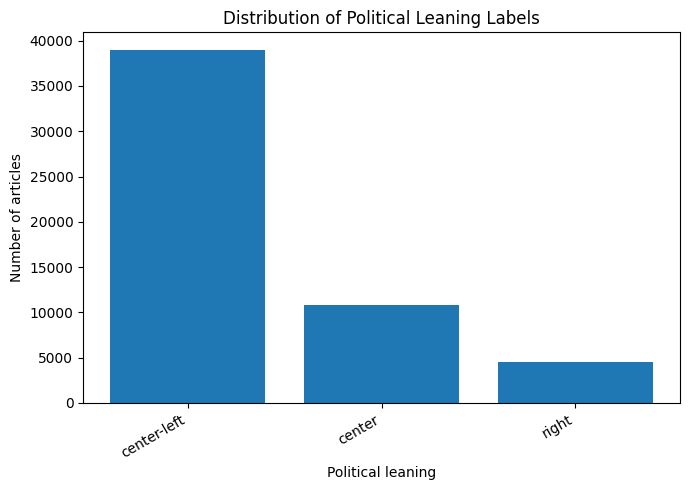

,leaning,count
2,center-left,38970
0,center,10817
1,right,4502


In [6]:
# Purpose: Visualise the target label imbalance.

label_counts_pdf = df_text.groupBy("leaning").count().toPandas().sort_values("count", ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(label_counts_pdf["leaning"], label_counts_pdf["count"])
plt.title("Distribution of Political Leaning Labels")
plt.xlabel("Political leaning")
plt.ylabel("Number of articles")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

label_counts_pdf


---
# **Model Selection and Implementation**
---


The preprocessing stages were defined separately before building the individual model pipelines because both Logistic Regression and Naive Bayes needed the same input format. The original dataset contained text labels and raw article text, but machine-learning models require numerical features and numerical target labels. Therefore, `StringIndexer` was used to convert the `leaning` labels into numerical label values, while tokenisation, stop-word removal, HashingTF, and IDF were used to convert article text into TF-IDF feature vectors.

Stemming and lemmatization were considered as additional preprocessing options, but they were not included in the final pipeline. Stemming reduces words to shorter root forms, while lemmatization converts words to dictionary-based base forms. These techniques can sometimes improve text classification by grouping related words together, but they can also add extra complexity and may remove wording differences that are still useful for classification. For this project, the PySpark pipeline focused on tokenisation, stop-word removal, HashingTF, and IDF because these stages provided a clear, scalable, and reproducible method for converting more than 54,000 articles into numerical features. Since the final tuned Logistic Regression model achieved strong performance without stemming or lemmatization, they were left as possible future preprocessing experiments.

Defining these stages once made the code cleaner and easier to compare across models. Instead of rewriting the same text-processing steps for Logistic Regression and Naive Bayes, the shared stages could be reused in each pipeline. This reduced repetition and helped make sure both models were trained on the same processed version of the data. As a result, the comparison between models was fairer because differences in performance were more likely to come from the model algorithms themselves rather than from different preprocessing choices.

The train/test split was also performed before model fitting to prevent data leakage. This ensured that the test data stayed unseen during training and was only used for final evaluation. A fixed random seed was used so the split could be reproduced consistently.

The evaluators were also defined once because the same metrics were used to assess both models. Accuracy, F1 score, weighted precision, and weighted recall were selected to provide a broader view of performance. This was especially important because the dataset was imbalanced, meaning accuracy alone could give an incomplete picture of model quality.

In [7]:
# Purpose: Split the data and define the shared text preprocessing stages.

# Index target labels.
label_indexer = StringIndexer(inputCol="leaning", outputCol="label")

# Split before fitting models to prevent test data leakage.
train_df, test_df = df_text.randomSplit([0.85, 0.15], seed=42)

print(f"Training rows: {train_df.count()}")
print(f"Test rows: {test_df.count()}")

# Shared text preprocessing stages.
tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashing_tf = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=20000)
idf = IDF(inputCol="raw_features", outputCol="features")

# Evaluators used for model comparison.
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
weighted_precision_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
weighted_recall_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")


Training rows: 46096


Test rows: 8193


The baseline models were defined separately from the final model so that the project had a clear starting point for comparison. A baseline model is useful because it shows how well a simple or initial version of the machine-learning approach performs before later improvements are added. Without a baseline, it would be harder to explain whether later changes, such as class weighting or parameter tuning, actually improved the model.

Logistic Regression was used as the main baseline model because it is a common and effective algorithm for text classification tasks. Naive Bayes was also included for comparison because it is often used with TF-IDF or word-frequency features and can perform well on text data. Testing both models made the model selection process more justified instead of choosing one algorithm without comparison.

Keeping the baseline pipelines separate also made the development process easier to explain. The baseline Logistic Regression model used the shared preprocessing stages but did not include later improvements such as class weights or formal parameter tuning. This allowed the final tuned Logistic Regression model to be compared against an earlier version of itself. Naive Bayes was later dropped because its accuracy and F1 score were consistently lower than Logistic Regression across the tested runs.

This separation therefore helped show the progression of the project: first, basic models were tested; then the stronger model was selected; finally, the selected model was improved using class weighting and formal parameter tuning.

In [8]:
# Purpose: Define baseline Logistic Regression and Naive Bayes pipelines.

# Baseline Logistic Regression model.
lr_baseline = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.0)

lr_baseline_pipeline = Pipeline(stages=[
    label_indexer,
    tokenizer,
    remover,
    hashing_tf,
    idf,
    lr_baseline])

# Naive Bayes model for comparison.
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="multinomial")

nb_pipeline = Pipeline(stages=[
    label_indexer,
    tokenizer,
    remover,
    hashing_tf,
    idf,
    nb])

# These baseline models were tested during development.
# Naive Bayes was later dropped because Logistic Regression consistently produced stronger results.


---
# **Model Parameter Tuning**
---


Class weighting was added during the later stages of tuning after different train/test splits had already been tested. Earlier model runs experimented with split ratios such as 80/20, 85/15, and 90/10 to see whether changing the amount of training data improved performance. After comparing these results, the 85/15 split was kept because it provided strong model performance while still leaving a large enough test set for evaluation.

Once the split decision was made, the next tuning focus was the class imbalance in the target labels. The dataset contained many more `center-left` articles than `center` or `right` articles, which meant the model could learn the majority class more strongly than the smaller classes. To address this, class weights were calculated from the training set only. This was important because the test set should remain unseen and should not influence training decisions.

The purpose of class weighting was to give greater importance to underrepresented classes during Logistic Regression training. The `right` class received the highest weight because it had the fewest examples, while the `center-left` class received the lowest weight because it had the most examples. This helped the model treat mistakes on smaller classes as more important during training.

Class weighting and formal parameter tuning were therefore the final stages of model improvement. The project first tested the effect of different data splits, then addressed class imbalance, and finally used formal tuning to test different Logistic Regression parameter values in a more systematic way.

In [9]:
# Purpose: Add class weights to address target label imbalance.

# Class weights are calculated from the training set only.
total_train = train_df.count()
label_counts = train_df.groupBy("leaning").count().collect()

class_weights = {
    row["leaning"]: total_train / (len(label_counts) * row["count"])
    for row in label_counts}

print("Class weights:")
print(class_weights)

train_df_weighted = train_df.withColumn(
    "class_weight",
    when(col("leaning") == "center-left", class_weights["center-left"])
    .when(col("leaning") == "center", class_weights["center"])
    .when(col("leaning") == "right", class_weights["right"]))

train_df_weighted.select("leaning", "class_weight").show(5)


Class weights:
{'center': 1.6812926286610497, 'right': 4.052039381153305, 'center-left': 0.4632996632996633}


+-----------+------------------+
|    leaning|      class_weight|
+-----------+------------------+
|     center|1.6812926286610497|
|     center|1.6812926286610497|
|center-left|0.4632996632996633|
|center-left|0.4632996632996633|
|center-left|0.4632996632996633|
+-----------+------------------+
only showing top 5 rows


This section represents the final fine-tuned version of the model. Earlier stages tested baseline Logistic Regression, Naive Bayes, different train/test splits, and class weighting. After those comparisons, Logistic Regression was selected as the strongest model, the 85/15 split was kept, and class weights were added to address the imbalance between `center-left`, `center`, and `right` articles.

The final stage was formal parameter tuning. Instead of manually choosing the final Logistic Regression settings, `TrainValidationSplit` was used to test multiple parameter combinations from a defined grid. This made the final model selection more systematic and easier to justify. The tuning process tested different values for `regParam`, which controls regularisation, and `maxIter`, which controls the maximum number of training iterations.

The evaluator used during tuning was F1 score because it provides a better balance between precision and recall than accuracy alone, especially when the dataset contains imbalanced classes. The training data was internally split again during `TrainValidationSplit`, allowing the model to compare parameter combinations without using the final test set. The final test set was only used after the best model had been selected.

This final model is therefore the completed version of the project pipeline: it uses the selected 85/15 train/test split, shared TF-IDF text preprocessing, Logistic Regression, class weighting, and formal parameter tuning. The best model was then used to generate predictions on the unseen test data for final evaluation.

In [10]:
# Purpose: Tune Logistic Regression parameters using TrainValidationSplit.

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=20,
    regParam=0.0)

lr_pipeline = Pipeline(stages=[
    label_indexer,
    tokenizer,
    remover,
    hashing_tf,
    idf,
    lr])

param_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr.maxIter, [10, 20])
    .build())

tvs = TrainValidationSplit(
    estimator=lr_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"),
    trainRatio=0.8,
    seed=42)

lr_model = tvs.fit(train_df_weighted)
lr_predictions = lr_model.transform(test_df)

best_lr_model = lr_model.bestModel
best_lr_stage = best_lr_model.stages[-1]

print("Sixth run: Logistic Regression with formal parameter tuning")
print("Best Logistic Regression parameters:")
print(f"Best regParam: {best_lr_stage.getRegParam()}")
print(f"Best maxIter:  {best_lr_stage.getMaxIter()}")


Sixth run: Logistic Regression with formal parameter tuning
Best Logistic Regression parameters:
Best regParam: 0.01
Best maxIter:  10


---
# **Model Evaluation and Accuracy Calculation**
---


In [11]:
# Purpose: Evaluate the tuned Logistic Regression model using standard multi-class metrics.

lr_accuracy = accuracy_eval.evaluate(lr_predictions)
lr_f1 = f1_eval.evaluate(lr_predictions)
lr_precision = weighted_precision_eval.evaluate(lr_predictions)
lr_recall = weighted_recall_eval.evaluate(lr_predictions)

print("Logistic Regression Results")
print(f"Accuracy:           {lr_accuracy:.4f}")
print(f"F1 Score:           {lr_f1:.4f}")
print(f"Weighted Precision: {lr_precision:.4f}")
print(f"Weighted Recall:    {lr_recall:.4f}")


Logistic Regression Results
Accuracy:           0.9402
F1 Score:           0.9404
Weighted Precision: 0.9407
Weighted Recall:    0.9402


In [17]:
# Purpose: Build a confusion matrix table from Spark predictions.

def get_confusion_matrix(predictions, label_model):
    labels = label_model.labels
    cm_df = predictions.groupBy("label", "prediction").count().toPandas()

    matrix = pd.DataFrame(0, index=labels, columns=labels)

    for _, row in cm_df.iterrows():
        true_label = labels[int(row["label"])]
        predicted_label = labels[int(row["prediction"])]
        matrix.loc[true_label, predicted_label] = row["count"]

    return matrix

label_model = lr_model.bestModel.stages[0]
confusion_matrix = get_confusion_matrix(lr_predictions, label_model)

print("Label mapping:", label_model.labels)
print("Confusion matrix table:")
print(confusion_matrix)

confusion_matrix


Label mapping: ['center-left', 'center', 'right']
Confusion matrix table:
             center-left  center  right
center-left         5568     213     24
center               172    1475     31
right                 20      30    660


,center-left,center,right
center-left,5568,213,24
center,172,1475,31
right,20,30,660


The model’s mistakes were investigated to understand not only how many predictions were wrong, but also how the model was failing. Accuracy and F1 score provide useful overall performance measures, but they do not fully explain which classes are causing problems. For this reason, the incorrect predictions were filtered into a separate `lr_mistakes` dataframe so that the article ID, source, true label, predicted label, probability, title, and content could be inspected.

This mistake analysis helped identify whether the model was making random errors or whether certain classes were being misclassified more often than expected. To check this, the distribution of mistakes was compared with the distribution of labels in the test set. This was important because the dataset was imbalanced. If one class made up a larger share of the test set, it would naturally be expected to produce more mistakes. However, if a class made up a much larger share of the mistakes than its share of the test set, that would suggest the model was struggling with that class.

In the earlier Logistic Regression results, the `center` class made up a disproportionate share of the mistakes compared with its percentage of the test data. This suggested that the model had more difficulty identifying politically central articles than the other labels. This may be because center-leaning articles can share language patterns with both center-left and right-leaning articles, making them harder to separate clearly.

Investigating mistakes helped guide later model improvement decisions. Since the model was struggling unevenly across classes, class weighting was added to reduce the effect of label imbalance and give more importance to underrepresented or harder-to-classify labels during training. This made the evaluation process more useful because it connected the model’s errors to a practical improvement strategy rather than only reporting final accuracy.

In [14]:
# Purpose: Inspect model mistakes and compare mistake distribution with test label distribution. Used at different stages of the workflow.

lr_mistakes = lr_predictions.filter(col("label") != col("prediction"))

print("Number of mistakes:", lr_mistakes.count())

show_preview(
    lr_mistakes.select(
        "article_id",
        "source",
        "leaning",
        "clean_title",
        "clean_content",
        "prediction",
        "probability"),
    n=10,
    text_cols=["clean_title", "clean_content"],
    text_len=1000,
    truncate=1200)

# Count mistakes by true label.
mistake_counts = lr_mistakes.groupBy("leaning").agg(count("*").alias("mistake_count"))
total_mistakes = lr_mistakes.count()

mistake_percentages = mistake_counts.withColumn(
    "mistake_percentage",
    round((col("mistake_count") / total_mistakes) * 100, 2))

# Count test rows by true label.
test_counts = test_df.groupBy("leaning").agg(count("*").alias("test_count"))
total_test = test_df.count()

test_percentages = test_counts.withColumn(
    "test_percentage",
    round((col("test_count") / total_test) * 100, 2))

comparison = (
    test_percentages
    .join(mistake_percentages, on="leaning", how="left")
    .fillna(0))

comparison.orderBy("leaning").show(truncate=False)


Number of mistakes: 490

Previewing dataframe:


-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+-----------+----------+---------------+-------------+------------------+
|leaning    |test_count|test_percentage|mistake_count|mistake_percentage|
+-----------+----------+---------------+-------------+------------------+
|center     |1678      |20.48          |203          |41.43             |
|center-left|5805      |70.85          |237          |48.37             |
|right      |710       |8.67           |50           |10.2              |
+-----------+----------+---------------+-------------+------------------+



---
# **Results Visualization or Printing**
---


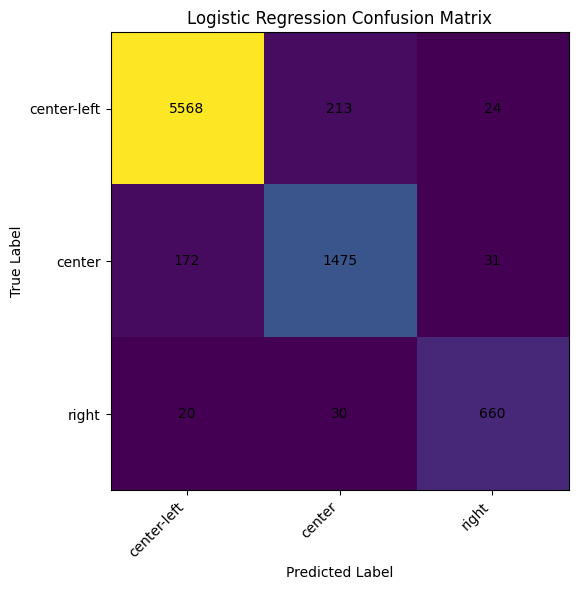

In [15]:
# Purpose: Plot and save the final Logistic Regression confusion matrix.

plots_folder = Path("outputs")
plots_folder.mkdir(exist_ok=True)

plt.figure(figsize=(7, 6))
plt.imshow(confusion_matrix.values)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(confusion_matrix.columns)), confusion_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(confusion_matrix.index)), confusion_matrix.index)

for i in range(len(confusion_matrix.index)):
    for j in range(len(confusion_matrix.columns)):
        plt.text(j, i, confusion_matrix.iloc[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(plots_folder / "logistic_regression_confusion_matrix.png", dpi=300)
plt.show()


In [16]:
# Purpose: Print a concise final results summary from the latest run.

print("Final selected model: Tuned Logistic Regression with class weights")
print("Train/test split: 85/15")
print("Best regParam: 0.01")
print("Best maxIter: 10")
print("Accuracy: 0.9402")
print("F1 Score: 0.9404")
print("Weighted Precision: 0.9407")
print("Weighted Recall: 0.9402")

print("""
Confusion matrix from latest provided run:
             center-left  center  right
center-left         5568     213     24
center               172    1475     31
right                 20      30    660

Mistake distribution compared with test label distribution:
center:      test 20.48%, mistakes 41.43%
center-left: test 70.85%, mistakes 48.37%
right:       test 8.67%,  mistakes 10.20%
""")


Final selected model: Tuned Logistic Regression with class weights
Train/test split: 85/15
Best regParam: 0.01
Best maxIter: 10
Accuracy: 0.9402
F1 Score: 0.9404
Weighted Precision: 0.9407
Weighted Recall: 0.9402

Confusion matrix from latest provided run:
             center-left  center  right
center-left         5568     213     24
center               172    1475     31
right                 20      30    660

Mistake distribution compared with test label distribution:
center:      test 20.48%, mistakes 41.43%
center-left: test 70.85%, mistakes 48.37%
right:       test 8.67%,  mistakes 10.20%



---
# **Development log and model selection decisions**

The project tested several versions of the model. The strongest model was the sixth run: Logistic Regression with class weights, an 85/15 train/test split, and formal parameter tuning.

| Run | Main change | Accuracy | F1 | Weighted precision | Weighted recall | Decision |
|---|---:|---:|---:|---:|---:|---|
| 1 | Baseline Logistic Regression | 0.9102 | 0.9122 | 0.9173 | 0.9102 | Continue testing |
| 1 | Baseline Naive Bayes | 0.7938 | 0.8045 | 0.8327 | 0.7938 | Weaker than Logistic Regression |
| 2 | 85/15 split | 0.9154 | 0.9171 | 0.9214 | 0.9154 | Logistic Regression improved |
| 3 | 90/10 split | 0.9182 | 0.9197 | 0.9234 | 0.9182 | Higher score, but smaller test set |
| 4 | 85/15 split + class weights | 0.9264 | 0.9262 | 0.9262 | 0.9264 | Stronger than previous best |
| 5 | 90/10 split + class weights | 0.9154 | 0.9171 | 0.9214 | 0.9154 | Worse than 85/15 weighted run |
| 6 | 85/15 split + class weights + tuning | **0.9402** | **0.9404** | **0.9407** | **0.9402** | Final selected model |

Naive Bayes was dropped because Logistic Regression consistently produced stronger accuracy and F1 scores. The 85/15 split was kept because it provided a larger and more representative test set than 90/10 while still producing strong results. Class weights were added because the target label distribution was imbalanced and earlier mistake analysis showed that the model struggled with `center` articles. Formal parameter tuning improved the final model further.

# Train/test split decision

The dataset was first split using common train/test logic. Common splits such as 70/30 and 80/20 are often used in machine learning because they reserve a clear portion of the data for testing while still leaving enough data for training. However, this project used a large dataset of 54,289 articles, so we wanted to explore whether giving the model more training data could improve performance without making the test set too small.

For this reason, we tested an 85/15 split. The decision was partly exploratory, but it was based on the idea that more training data can help the model learn stronger text patterns. Instead of moving toward a 75/25 “middle” split, we moved toward 85/15 because the dataset was large enough to still leave thousands of articles for testing. The 85/15 split produced 46,096 training rows and 8,193 test rows, which meant the model still had a reasonably large test set.

A 90/10 split was also considered because it gives the model even more training data. However, we decided not to keep it because the test set becomes smaller and may be less representative of the overall dataset. Although high accuracy is important, the evaluation also needs to be reliable. If the test set is too small or less representative, the reported accuracy may look strong but may not reflect how well the model would perform on unseen articles. In the final tests, the 85/15 split with class weighting performed better than the 90/10 split with class weighting, so the 85/15 split was kept.

# Class weighting explanation

The dataset was imbalanced because the number of center-left, center, and right articles was not equal. Center-left articles made up the majority of the dataset, while right-leaning articles were the smallest class. This imbalance can cause a model to become biased toward the majority class because predicting the majority label more often can still produce a high overall accuracy.

To reduce this problem, class weights were added to Logistic Regression. Class weighting gives more importance to minority classes during training. In this project, the right-leaning class received the highest weight because it had the fewest training examples. The center class also received a higher weight than center-left. The center-left class received the lowest weight because it was already heavily represented in the dataset.

This helped the model pay more attention to underrepresented classes instead of mainly learning patterns from the center-left articles. After adding class weights, the model achieved stronger performance than the earlier unweighted Logistic Regression runs.

# Formal parameter tuning explanation

Formal parameter tuning was used to improve the Logistic Regression model in a more systematic way. Instead of manually choosing one set of parameters, the code tested multiple combinations and selected the best-performing version using F1 score.

The tuning process used TrainValidationSplit. This means the training data was divided again internally: part of it was used to train the model, and part of it was used to validate different parameter combinations. The model did not use the final test set during this tuning process. This is important because the test set should remain unseen until final evaluation.

The parameters tested were:
- regParam: controls regularisation. Regularisation helps prevent the model from overfitting by discouraging overly complex patterns.
- maxIter: controls how many training iterations Logistic Regression can use to optimise its solution.

The parameter grid tested different values for these settings. The best model selected had regParam = 0.01 and maxIter = 10. This means a small amount of regularisation improved the model, while 10 iterations were enough for the best validation result. After formal tuning, the final Logistic Regression model achieved the strongest results: 94.02% accuracy and 94.04% F1 score.

---
# **LSEP Considerations**
---


# **Legal, Social, Ethical and Professional considerations**

## Legal considerations

This project uses news article text for machine-learning classification. News articles may be copyrighted, so the dataset should only be used in ways permitted by the dataset licence, university coursework rules, and fair dealing/fair use expectations. The notebook should not republish full articles unnecessarily. For model inspection, only limited previews of article text are printed.

## Social considerations

Political leaning classification can affect how readers interpret news sources. A model prediction should not be presented as an objective truth about an article or publisher. It is only a statistical classification based on patterns in the labelled dataset. The model may also reflect the assumptions, collection methods, and label definitions used by the dataset creator.

A political bias classification model can still be socially useful, especially because many people now consume news through algorithmic feeds on social media and online platforms. These systems can contribute to echo chamber effects, where users repeatedly see information that supports their existing views. A model that identifies likely political leaning could help users become more aware of the balance or imbalance in the news content they read.

Bias disclosure is important because readers may not always recognise political framing. A classifier could support transparency by helping users compare articles from different perspectives or recognise when their media diet is dominated by one viewpoint. However, this should be presented as guidance rather than as a final judgement.

## Ethical considerations

The model could reinforce bias if its labels are treated as absolute. It may also misclassify articles about sensitive political issues, public figures, immigration, war, crime, or social identity. The model should therefore be used for analysis and education rather than to censor, suppress, or unfairly rank news organisations. Mistake analysis is important because the model performed differently across classes.

There is also an ethical issue around how political labels are created. Political bias can be difficult to define objectively, and the initial labels may already contain human, institutional, or source-level assumptions. For example, a publisher may usually be labelled as one political leaning, but an individual article from that publisher may be more neutral or may discuss a topic in a different way. This means the model may learn source-related patterns as well as article-content patterns.

For this reason, the model should not be treated as a final authority on political bias. Its predictions should be interpreted carefully and, where possible, supported by human review and transparent explanation.

## Professional considerations

The project should be reported transparently. This includes explaining class imbalance, documenting model selection decisions, reporting multiple metrics instead of only accuracy, and acknowledging limitations. The final model achieved strong performance, but it still made mistakes, especially around the `center` class. A professional deployment would need more validation, updated data, monitoring for drift, and careful review before real-world use.

A further professional limitation is the lack of a universally accepted benchmark for political bias classification. Different organisations, researchers, and readers may disagree about what counts as `center`, `center-left`, or `right`. Therefore, any real-world version of this system would need clear labelling standards, documentation of how labels were assigned, and regular review to make sure the model remains fair, explainable, and reliable.


# **Report HTML template**

This notebook is organised to follow the coursework structure and help the reader move through the report:

1. Spark setup
2. Dataset description and research objectives
3. Data loading, preprocessing, and visualisation
4. Model selection and implementation
5. Parameter tuning
6. Evaluation and accuracy calculation
7. Results visualisation and printed results
8. LSEP considerations
9. HTML conversion commands


In [18]:
# install nbconvert (if facing the conversion error)
!pip3 install nbconvert



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [20]:
# Convert ipynb to HTML
!jupyter nbconvert --to html Lab09_Group01_CRWK_CN7030_Political_Bias.ipynb


[NbConvertApp] Converting notebook Lab09_Group01_CRWK_CN7030_Political_Bias.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('jetTransient' was unexpected)

Failed validating 'additionalProperties' in display_data:

On instance['cells'][10]['outputs'][1]:
{'data': {'image/png': 'iVBORw0KGgoAAAANSUhEUgAAArIAAAHqCAYAAAD4TK2HAAAAOnRFWHRTb2Z0d2Fy...',
          'text/plain': '<Figure size 700x500 with 1 Axes>'},
 'jetTransient': {'display_id': None},
 'metadata': {},
 'output_type': 'display_data'}
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 633174 bytes to Lab09_Group01_CRWK_CN7030_Political_Bias.html
